# Random Forest Model Implementation on BookMeas Dataset

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import pyarrow.parquet as pq
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
bookmeas_dataset = r"D:\Universität\Master\Semester2\RealWorld_ML_Problems\Data\output\bookmeas\bookmeas_e_2025-03-19_to_2025-03-28_cleaned_spearman.parquet"

In [3]:
df_bo_me = pd.read_parquet(bookmeas_dataset)
df_bo_me = df_bo_me.dropna()

In [4]:
label_col = 'target'
y = df_bo_me[label_col]
print(df_bo_me[label_col].value_counts())

target
0.0    942256
1.0       181
Name: count, dtype: int64


In [6]:
X = df_bo_me.drop(columns=["target"])

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

### (Logistic Regression first try)

In [8]:
model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
model = LogisticRegression()
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [9]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    188452
         1.0       0.87      0.56      0.68        36

    accuracy                           1.00    188488
   macro avg       0.93      0.78      0.84    188488
weighted avg       1.00      1.00      1.00    188488

Confusion Matrix:
 [[188449      3]
 [    16     20]]
ROC-AUC: 0.9997202352735858


In [10]:
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [11]:
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    188452
         1.0       1.00      1.00      1.00        36

    accuracy                           1.00    188488
   macro avg       1.00      1.00      1.00    188488
weighted avg       1.00      1.00      1.00    188488

Confusion Matrix:
 [[188452      0]
 [     0     36]]
ROC-AUC: 1.0


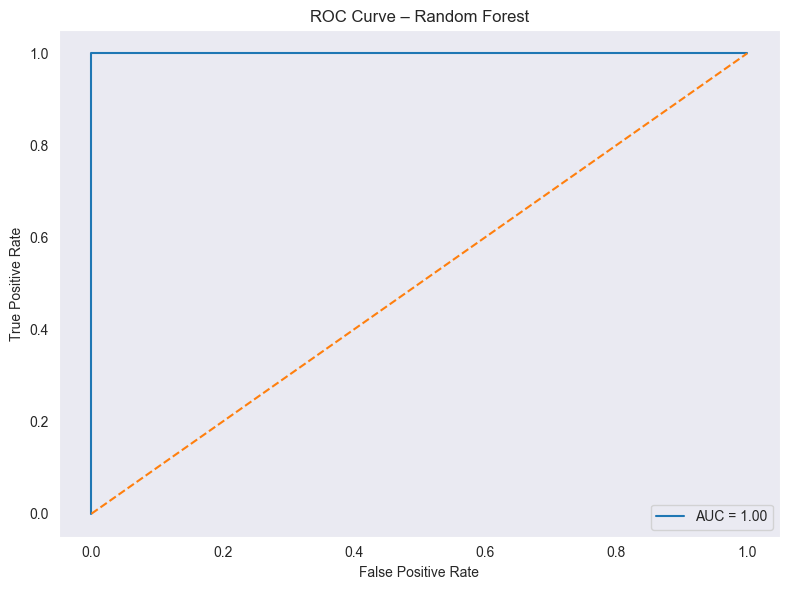

In [12]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_proba):.2f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – Random Forest')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

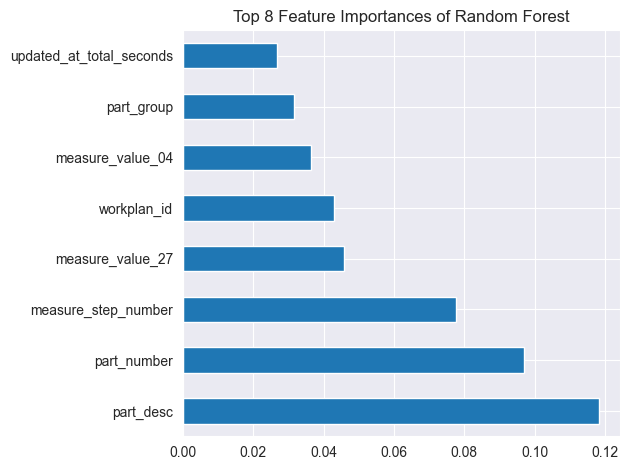

In [13]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.nlargest(8).plot(kind='barh')
plt.title("Top 8 Feature Importances of Random Forest")
plt.tight_layout()
plt.show()